In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import time
import numpy as np
from loguru import logger
import warnings
warnings.filterwarnings("ignore")

#data loading
csv_basic = '../../Data/important/basic_eth_100d_scam.csv'
csv_scam = '../../Data/important/info_eth_100dscam.csv'
csv_scamliq = '../../Data/important/liq_eth_100d_scam.csv'
csv_rugpullseller = '../../Data/important/analysis/rugpull_sellers.csv'
csv_unique_wallet = '../../Data/important/analysis/unique_wallets.csv'


df_scaminfo = pd.read_csv(csv_scam)
df_scamliq = pd.read_csv(csv_scamliq)
df_rugpullseller = pd.read_csv(csv_rugpullseller)
df_unique_wallet = pd.read_csv(csv_unique_wallet)


pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

print('Done data loading')

In [7]:
df_rugpullseller = df_rugpullseller.merge(
    df_scaminfo[['pool_address', 'token_owner']],
    on='pool_address',
    how='left'
)

In [8]:
df_rugpullseller.to_csv(csv_rugpullseller, index=False)

In [ ]:
summary = (
    df_rugpullseller.groupby(['created_year', 'seller_count'])
    .size()
    .reset_index(name='count')
)

mask = summary['seller_count'].between(1, 10)
total_1_10 = summary.loc[mask, 'count'].sum()
proportion_1_10 = total_1_10 / total
print('Total (seller_count 1-10):', total_1_10)
print('Proportion (seller_count 1-10):', proportion_1_10)

summary['proportion'] = summary.groupby('created_year')['count'].transform(lambda x: x / x.sum())


prop_seller1 = summary[summary['seller_count'] == 1].set_index('created_year')['proportion']
print(prop_seller1)

print(top10)

Total (seller_count 1-10): 29573
Proportion (seller_count 1-10): 0.2804882675417797
created_year
2018    0.250000
2019    0.578947
2020    0.477486
2021    0.302792
2022    0.251270
2023    0.247541
2024    0.283948
Name: proportion, dtype: float64
    created_year  seller_count  count  proportion
0           2018             2      3    0.750000
1           2018             1      1    0.250000
2           2019             1     44    0.578947
3           2019             2     15    0.197368
4           2019             3     11    0.144737
..           ...           ...    ...         ...
56          2024             6    817    0.029358
57          2024             7    710    0.025513
58          2024             8    697    0.025046
59          2024            10    566    0.020338
60          2024             9    546    0.019620

[61 rows x 4 columns]


In [1]:
year_lo, year_hi = 2018, 2024
g = df_rugpullseller.copy()
g = g[(g['created_year'] >= year_lo) & (g['created_year'] <= year_hi)]

ct = (
    g.groupby(['created_year', 'seller_count'])
      .size()
      .rename('n')
      .reset_index()
)

years = pd.Index(range(year_lo, year_hi + 1), name='created_year')

ct_1_2 = ct[ct['seller_count'].isin([1, 2])].groupby('created_year')['n'].sum().reindex(years, fill_value=0)

ct_gt10 = ct[ct['seller_count'] > 5].groupby('created_year')['n'].sum().reindex(years, fill_value=0)


year_tot = g.groupby('created_year').size().reindex(years, fill_value=0).replace(0, np.nan)

pct_1_2 = (ct_1_2 / year_tot * 100).fillna(0)
pct_gt10 = (ct_gt10 / year_tot * 100).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(years, pct_1_2, label='seller_count = 1 or 2', linewidth=1.8)
ax.plot(years, pct_gt10, label='seller_count > 5', linewidth=1.8)

ax.set_xlabel('LP Created Year', fontweight='bold', fontsize=14)
ax.set_ylabel('Labeled LPs proportion (%)', fontweight='bold', fontsize=14)
ax.set_xticks(years)
ax.set_xlim(year_lo, year_hi)
ax.set_ylim(0, max(100, np.ceil(max(pct_1_2.max(), pct_gt10.max())/5)*5))
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=12, frameon=False)

plt.show()


NameError: name 'df_rugpullseller' is not defined

In [10]:
import ast

def owner_in_sellers(row):
    sellers = ast.literal_eval(row['rugpull_sellers'])
    return row['token_owner'] in sellers

df_owner_in_sellers = df_rugpullseller[df_rugpullseller.apply(owner_in_sellers, axis=1)]
df_owner_in_sellers

,pool_address,rugpull_sellers,seller_count,pool_created_time,created_year,token_owner
5,0xbaf5A8BDF81cfE2d34c0CeD89236FE473183F2E8,"[""0x8948E4B00DEB0a5ADb909F4DC5789d20D0851D71""]",1,2019-03-07 05:59:20,2019,0x8948E4B00DEB0a5ADb909F4DC5789d20D0851D71
7,0x9394C20adca4512DfC3d3c184c648E4193462Ebb,"[""0x2523C15dB0e3843DfC7C08772c8331Fb40CC8a0F""]",1,2019-04-22 08:02:06,2019,0x2523C15dB0e3843DfC7C08772c8331Fb40CC8a0F
10,0xEda88dDb13888C9A4dE7304965E9315E69ea980E,"[""0x866cb16F2162c319E48351827A7e15DDf0405E16""]",1,2019-06-10 00:06:22,2019,0x866cb16F2162c319E48351827A7e15DDf0405E16
11,0xC2a27366Deb7530Bd7F812C69d48B0215e397771,"[""0x9c5670F3B14Ae6919218242f8388D71A397C20B9"",...",6,2019-06-25 18:02:32,2019,0x9c5670F3B14Ae6919218242f8388D71A397C20B9
17,0x06bcA45DDf2Ff3F1155F556CeC95c8dB86aB8167,"[""0x31D63C562b5e33495e1aC769571068f652a98692""]",1,2019-06-30 21:37:15,2019,0x31D63C562b5e33495e1aC769571068f652a98692
...,...,...,...,...,...,...
105417,0x478CB96B1BEF5942b7DD9D57Baa51905d9749651,"[""0x049F08eADa6A915758033aCFd4389772311f1fDa"",...",36,2024-11-30T13:14:11Z,2024,0x2838B9e3D26F4530ea98966d69FdFCdC88aB9aB4
105427,0xd98d929EBc79856BBaEB783561294999c424211B,"[""0x670C625612D1662c91dc7B4434207101e7bd941f""]",1,2024-11-30T20:59:23Z,2024,0x670C625612D1662c91dc7B4434207101e7bd941f
105428,0x6E7FE3428816cbD1CB1788aa84d04C4a08248b02,"[""0x670C625612D1662c91dc7B4434207101e7bd941f""]",1,2024-11-30T21:41:47Z,2024,0x670C625612D1662c91dc7B4434207101e7bd941f
105430,0x6555fD6e6a1f048030314a26c5BFdfb42c9D3512,"[""0xf3c739AC6db9258D6152CBA121a96Fb9F5B7Efd8""]",1,2024-11-30T23:01:11Z,2024,0xf3c739AC6db9258D6152CBA121a96Fb9F5B7Efd8


In [ ]:
34927/105434

0.3312688506553863

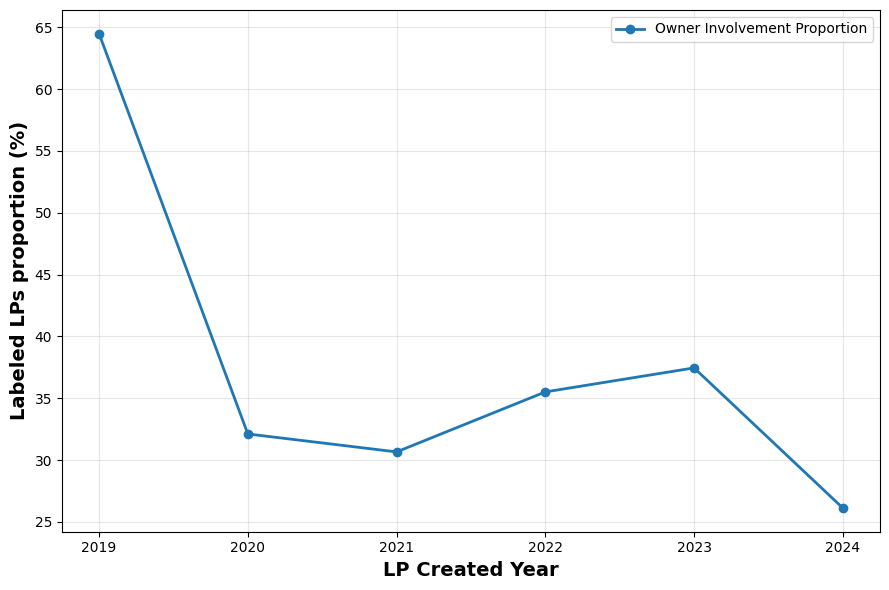

created_year
2019    0.644737
2020    0.321171
2021    0.306664
2022    0.355162
2023    0.374578
2024    0.261310
Name: owner_involvement_proportion, dtype: float64


In [ ]:
# Calculate the proportion of pools where token_owner is in rugpull_sellers for each created_year (year > 2018)
owner_involvement = (
    df_owner_in_sellers[df_owner_in_sellers['created_year'] > 2018]
    .groupby('created_year').size() / df_rugpullseller[df_rugpullseller['created_year'] > 2018]
    .groupby('created_year').size()
).rename('owner_involvement_proportion')

owner_involvement = owner_involvement.reindex(years[years > 2018], fill_value=0)

plt.figure(figsize=(9, 6))
plt.plot(owner_involvement.index, owner_involvement.values * 100, marker='o', linewidth=2, label='Owner Involvement Proportion')
plt.xlabel('LP Created Year', fontweight='bold', fontsize=14)
plt.ylabel('Labeled LPs proportion (%)', fontweight='bold', fontsize=14)
plt.xticks(owner_involvement.index)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(owner_involvement)

Number of pools created in 2018: 4
